In [8]:

# Sample dataset of movies with their genres and descriptions

data = {
    "Title": [
        "Inception", "The Godfather", "Interstellar", "Pulp Fiction", 
        "The Terminator", "Se7en", "Minority Report", "Hidden Figures", 
        "Pi", "The Matrix"
    ],
    "Genre": [
        "Sci-Fi", "Crime", "Sci-Fi", "Crime", 
        "Action", "Thriller", "Sci-Fi", "Drama", 
        "Thriller", "Sci-Fi"
    ],
    "Description": [
        "A thief steals corporate secrets through dream-sharing technology.",
        "An aging patriarch transfers control of his empire to his son.",
        "Explorers travel through a wormhole to ensure humanity's survival.",
        "The lives of hitmen, a boxer, and a gangster intertwine.",
        "A cyborg assassin is sent back in time to kill a woman.",
        "Two detectives hunt a serial killer obsessed with the seven deadly sins.",
        "Police apprehend criminals before they even commit a crime.",
        "Female mathematicians play a vital role in NASA's early years.",
        "A mathematician searches for a pattern that unlocks nature's secrets.",
        "A hacker discovers reality is a simulation controlled by machines."
    ]
}

In [9]:

# Importing essential libraries
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance
from sentence_transformers import SentenceTransformer

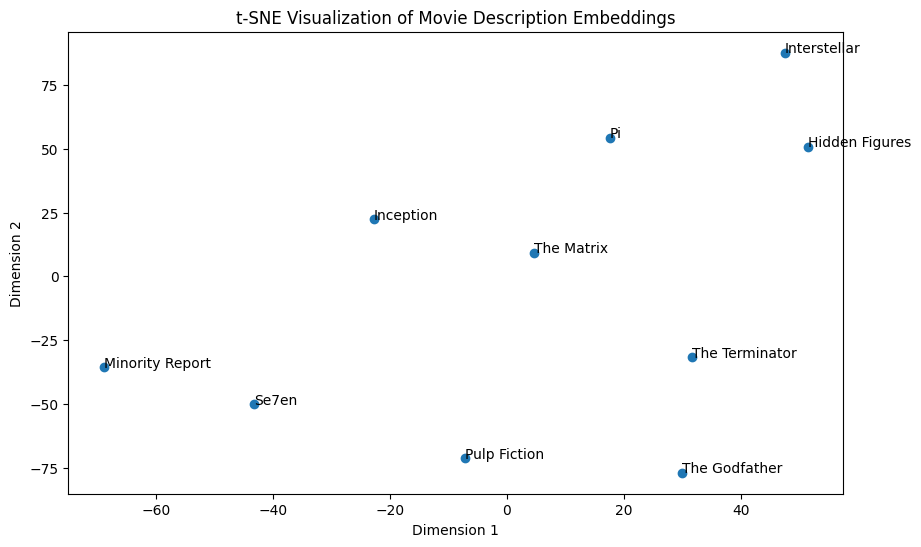

In [16]:
# initialize the model using the pre-trained 'all-MiniLM-L6-v2' model from Sentence Transformers
model = SentenceTransformer('all-MiniLM-L6-v2') # This avoids the use of dedicated api keys and allows for local embedding generation without external dependencies.

# extracting the embeddings for the movie descriptions
embeddings = model.encode(data["Description"]).tolist()

# Mapping the embeddings on a 2D plane using t-SNE for visualization
tsne = TSNE(n_components=2, perplexity=5)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

# Creating a DataFrame for visualization
df = pd.DataFrame({
    "Title": data["Title"],
    "Genre": data["Genre"],
    "Description": data["Description"]})

# plotting the embeddings in a 2D space
plt.figure(figsize=(10, 6))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
for i, title in enumerate(df["Title"]):
    plt.annotate(title, (embeddings_2d[i, 0], embeddings_2d[i, 1]))
plt.title("t-SNE Visualization of Movie Description Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

In [17]:
# Comparing the cosine distances between the genre and movie descriptions to find similarities

def find_n_dist(query_vec, embed, n=3 ):
    distances = []
    for i, vec in enumerate(embed):
        dist = distance.cosine(query_vec, vec)
        distances.append({"Distance": dist, "Index": i})
        sorted_distances = sorted(distances, key=lambda x: x["Distance"])
    return sorted_distances[:n]

# generating the embedding for sample genre "romance"
query_genre = "romance"
query_vec = model.encode([query_genre])[0]
similar_movies = find_n_dist(query_vec, embeddings)
print(f"Movies close to genre '{query_genre}':")
for movie in similar_movies:
    print(f"{df['Title'][movie['Index']]}")

Movies close to genre 'romance':
Pulp Fiction
Hidden Figures
Pi
